### Prepare and analysis data

In [1]:
import pandas as pd
import json
import matplotlib.pyplot as plt
import seaborn as sns

from underthesea import word_tokenize
from collections import Counter

#### Đọc dữ liệu

In [ ]:
# Load the data from json files
data_path = "../data/"
df = json.load(open(data_path + "train.json", "r"))

# Convert the data to pandas DataFrame
df = pd.DataFrame(df)
# in 5 dòng dữ liệu


#### Xem qua dữ liệu TRAIN

In [3]:
# glance dữ liệu trên tập train trước
df.info()
print('\nIn 5 dòng đầu đề có cái nhìn trực quan về dữ liệu:')
display(df.head())

<class 'pandas.DataFrame'>
RangeIndex: 428448 entries, 0 to 428447
Data columns (total 4 columns):
 #   Column       Non-Null Count   Dtype
---  ------       --------------   -----
 0   instruction  428448 non-null  str  
 1   en           428448 non-null  str  
 2   vi           428448 non-null  str  
 3   len_vi       428448 non-null  int64
dtypes: int64(1), str(3)
memory usage: 13.1 MB

In 5 dòng đầu đề có cái nhìn trực quan về dữ liệu:


,instruction,en,vi,len_vi
0,I need these sentences to be translated into V...,His narrative stretches over 30 years of his l...,Cuốn sách là lời tự thuật của Saleem về 30 năm...,34
1,Please convert these English sentences into Vi...,These include the greatest enigma of all: Sale...,Tất cả tạo ra điều bí ẩn vĩ đại nhất: Saleem s...,30
2,I require the translation of these English sen...,All children born in and around the stroke of ...,Mọi đứa trẻ sinh ra trong khoảng nửa đêm đều s...,40
3,Please assist me in translating these sentence...,"With his powers of telepathy, Saleem forges co...","Với khả năng thần giao cách cảm, Saleem kết nố...",56
4,Please convert these English sentences into Vi...,"Independence also coincided with Partition, wh...","Độc lập đồng thời tạo ra sự chia cắt, khi Ấn Đ...",30


#### Phân tích và tiền xử lý

In [ ]:
# Đầu tiên nhận thấy rằng cột "instruction" không cần thiết cho việc huấn luyện mô hình dịch máy, 
# vì nó chỉ chứa thông tin về cách thức dịch mà không ảnh hưởng trực tiếp đến nội dung của câu. 
# Do đó, chúng ta sẽ loại bỏ cột này khỏi DataFrame trước khi tiếp tục phân tích độ dài của các câu.
df = df.drop(['instruction'], axis=1)

# Ta ta có cột len_vi mà không có cột len_en, nên ta sẽ tạo cột len_en để tính độ dài của câu tiếng Anh.
df['len_en'] = df['en'].apply(lambda x: len(x.split()))

# Bây giờ chúng ta có thể tính toán các thống kê cơ bản về độ dài của các câu tiếng Việt và tiếng Anh.
df.describe()

,len_vi,len_en
count,428448.000000,428448.000000
mean,42.253419,31.381573
std,12.382845,10.065146
min,30.000000,9.000000
25%,33.000000,24.000000
50%,38.000000,29.000000
75%,47.000000,36.000000
max,100.000000,133.000000


Dữ độ dài trên, ta thấy có vẻ dữ liệu hơi lệch phải, nếu cầu chắc chắn thì để plot histogram xem sao.

Nhưng dù thế nào thì với độ dài trên, ta thấy nó cũng hơi ảnh hưởng nếu dùng RNN rồi.

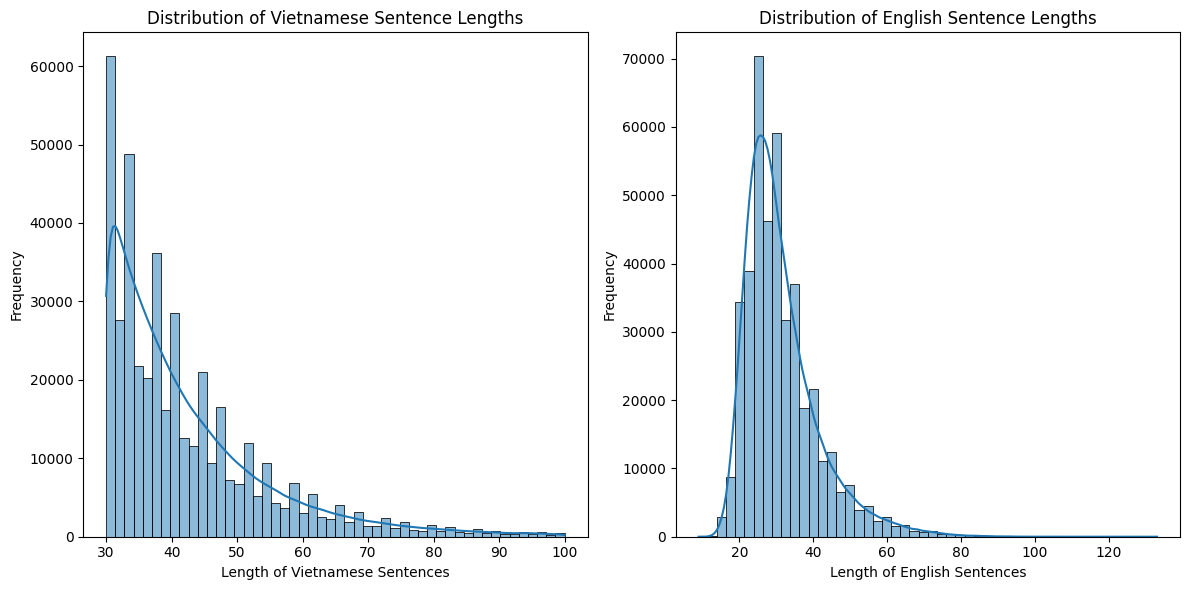

In [5]:
# Vẽ biểu đồ phân phối độ dài của các câu tiếng Việt và tiếng Anh để có cái nhìn trực quan hơn về dữ liệu.
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
sns.histplot(df['len_vi'], bins=50, kde=True)
plt.title('Distribution of Vietnamese Sentence Lengths')
plt.xlabel('Length of Vietnamese Sentences')
plt.ylabel('Frequency')

plt.subplot(1, 2, 2)
sns.histplot(df['len_en'], bins=50, kde=True)
plt.title('Distribution of English Sentence Lengths')
plt.xlabel('Length of English Sentences')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

Dữ liệu tiếng Anh thì lệch nhẹ hơn, nhưng dữ liệu tiếng Việt bị lệch nặng quá, chắc chắn cần cắt bớt rồi

Ngoài ra dữ liệu tiếng Việt cũng khá thiếu tự nhiên, `sao câu ngắn nhất cũng là 30 từ?` -> khả năng cao là đã bị động tay qua rồi.

Plot coi thử vấn đề này và ta cũng xem qua liệu rằng độ dài có tương quan không, thường thì **Dữ liệu dịch máy chuẩn thì câu nguồn dài, câu đích cũng phải dài tương ứng.**

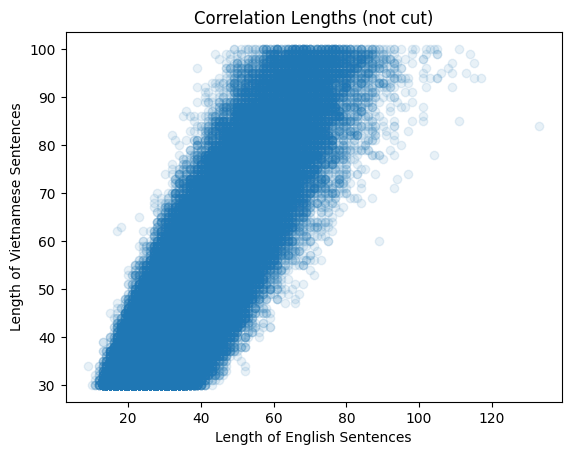

In [6]:
plt.scatter(df['len_en'], df['len_vi'], alpha=0.1)
plt.xlabel('Length of English Sentences')
plt.ylabel('Length of Vietnamese Sentences')
plt.title('Correlation Lengths (not cut)')
plt.show()

Rõ ràng plot ra ta thấy có vẻ như thực sự người cung cấp dữ liệu đã cắt bớt các câu <30 và >100 đi rồi, cân nhắc có cần cắt đi thêm không.

Thêm nữa thì có vẻ có sự tương quan độ dài, nhưng chênh lệch khá mạnh cho tiếng Việt, cái này thì không quá ngoài dự đoán, tiếng Việt là ngôn ngữ đơn âm, ví dụ `student` sẽ được dịch thành `học` và `sinh`, nên độ dốc khoảng x1-2 là có thể hiểu.

In [7]:
# Giả sử nếu chúng ta muốn cắt các câu dài hơn một độ dài nhất định để giảm thiểu sự mất mát thông tin, 
# chúng ta có thể quyết định một giá trị max_length dựa trên phân phối độ dài của các

max_len_vi = df['len_vi'].quantile(0.95)  # Chọn độ dài tối đa cho tiếng Việt tại 95% của phân phối
max_len_en = df['len_en'].quantile(0.95)  # Chọn độ dài tối đa cho tiếng Anh tại 95% của phân phối
print(f"Max length for Vietnamese sentences: {max_len_vi}")
print(f"Max length for English sentences: {max_len_en}")

# Chọn độ dài tối đa cho cả hai ngôn ngữ để đảm bảo rằng chúng ta giữ lại phần lớn dữ liệu mà không bị mất quá nhiều thông tin.
max_len = int(max(max_len_vi, max_len_en))
print(f"Chosen max length for both languages: {max_len}")

Max length for Vietnamese sentences: 68.0
Max length for English sentences: 51.0
Chosen max length for both languages: 68


#

In [12]:
# Đếm số từ trong cột "en" và "vi" để có cái nhìn về kích thước từ vựng của cả hai ngôn ngữ.
vi_vocab = Counter([word for sentence in df['vi'] for word in sentence.split()])

# số lượng từ trong cột "vi"
print(f"Số lượng từ trong cột 'vi': {len(vi_vocab)}")

# Hiển thị 10 từ phổ biến nhất trong cột "vi"
print("10 từ phổ biến nhất trong cột 'vi':")
for word, count in vi_vocab.most_common(10):
    print(f"{word}: {count}")

Số lượng từ trong cột 'vi': 380258
10 từ phổ biến nhất trong cột 'vi':
và: 365823
của: 302916
một: 246906
có: 222283
là: 212627
các: 201221
được: 180060
trong: 172402
với: 137348
đã: 133212


In [13]:
# Với hiểu biết về sự chênh lệch khi dịch tiếng Việt và Anh, tạo dữ liệu vi_tokened xem có cải thiện gì không
df1 = df.copy()
df1['vi_tokened'] = df1['vi'].apply(lambda x: word_tokenize(x))

vi_vocab = Counter([word for sentence in df1['vi_tokened'] for word in sentence])

# số lượng từ trong cột "vi_tokened"
print(f"Số lượng từ trong cột 'vi_tokened': {len(vi_vocab)}")

# Hiển thị 10 từ phổ biến nhất trong cột "vi_tokened"
print("10 từ phổ biến nhất trong cột 'vi_tokened':")
for word, count in vi_vocab.most_common(10):
    print(f"{word}: {count}")

Số lượng từ trong cột 'vi_tokened': 404427
10 từ phổ biến nhất trong cột 'vi_tokened':
,: 817042
.: 418650
và: 367598
của: 303594
một: 214378
các: 201836
là: 199448
được: 184564
trong: 173684
đã: 133642


In [14]:
# Tương tự, ta cũng có thể đếm từ các "từ" xuất hiện trong cột "en" để xem tần suất của chúng. 
# Ta chỉ split thôi chứ không tokenized vì tiếng Anh đã được tách từ bằng dấu cách.
en_vocab = Counter([word for sentence in df['en'] for word in sentence.split()])

# số lượng từ trong cột "en"
print(f"Số lượng từ trong cột 'en': {len(en_vocab)}")

# Hiển thị 10 từ phổ biến nhất trong cột "en"
print("10 từ phổ biến nhất trong cột 'en':")
for word, count in en_vocab.most_common(10):
    print(f"{word}: {count}")

Số lượng từ trong cột 'en': 509573
10 từ phổ biến nhất trong cột 'en':
the: 690978
of: 410516
and: 403343
to: 356615
a: 285767
in: 271520
that: 146684
is: 131209
-: 122542
for: 106165


Hầu hết là các stop words, thường thì ta cần thực hiện loại bỏ các stop words này tránh gây nhiễu thông tin

Nhưng trong bài toán NMT thì không cần loại stop words, mà cũng không nên loại